In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [2]:
train = pd.read_csv("train.csv")

In [3]:
train

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

In [ ]:
model.compile()

In [5]:
def split_x_and_y(df, target):
    """
    Split into x and y utility function
    """
    X = df[[col for col in df.columns if col != target]]
    y = df[target]
    return X, y


X, y = split_x_and_y(train, "label")

In [6]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=["accuracy"],
)

In [7]:
X.shape

(42000, 784)

In [8]:
train_images = X.astype("float32") / 255

In [10]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [11]:
model.fit(X, y, epochs=5, batch_size=128)

Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8993 - loss: 5.2333 
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9532 - loss: 0.9144
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9662 - loss: 0.4391
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9724 - loss: 0.3071
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.2027


In [28]:
test_images = pd.read_csv("test.csv")
test_images = test_images.astype("float32") / 255

In [29]:
predictions_mnist = model.predict(test_images)

875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step


In [30]:
predictions_mnist[0].argmax()

np.int64(2)

In [31]:
import matplotlib.pyplot as plt

four = X.iloc[3, :].values.reshape(28, 28)

four

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 220, 179,   6,   0,   0,   0,   0,
          0,   0,   0,   0,   9,  77,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

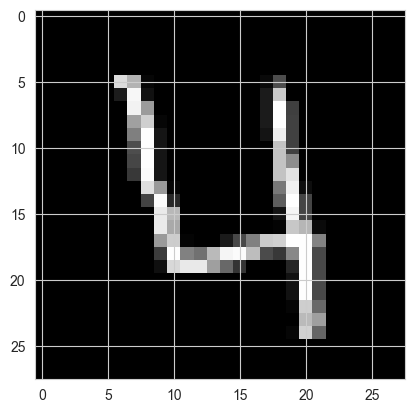

In [32]:
plt.imshow(four, cmap="gray")

In [35]:
predictions_mnist[3].argmax()

np.int64(0)

In [36]:
model.evaluate(X, y)

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 415us/step - accuracy: 0.9849 - loss: 0.1240


[0.12400825321674347, 0.9848571419715881]